# Challenge 2: Image Classification

## Hyperparameters

In [11]:
# --- Stochasticity -- 
SEED = 100

VALIDATION_SIZE = 0.2
IMAGE_SIZE = 512

# --- Model Parameters ---
MODEL_TYPE = 'ResNet50'
PRETRAINED = True
NUM_CLASSES = 10

# --- Training Hyperparameters ---
LEARNING_RATE = 0.0001
BATCH_SIZE = 64
EPOCHS = 300
PATIENCE = 50
OPTIMIZER = 'AdamW'

# Regularisation
DROPOUT_RATE = 0.2       
L1_LAMBDA = 0             
L2_LAMBDA = 0            

# Plot config
PLOT_FLAG = True

# --- Data Settings ---
WHITELIST_PATH = 'whitelist/super_clean_train_data.txt'

TRAIN_DATA_PATH = 'train_data'
TRAIN_IMAGES_CACHE_PATH = 'cache/train_images_cache.npy'
TRAIN_MASKS_CACHE_PATH = 'cache/train_masks_cache.npy'
TRAIN_MASKED_IMAGES_CACHE_PATH = 'cache/train_masked_images_cache.npy' 
TRAIN_LABEL_PATH = 'train_labels.csv'

TEST_DATA_PATH = 'test_data'
TEST_IMAGE_CACHE_PATH  = 'cache/test_images_cache.npy'
TEST_MASKS_CACHE_PATH = 'cache/test_masks_cache.npy'
TEST_MASKED_IMAGES_CACHE_PATH = 'cache/test_masked_images_cache.npy' 




## Module imports

In [12]:
import cplot

import os
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
import torchvision
from torchvision.transforms import v2 as transforms
from torch.utils.data import TensorDataset, DataLoader
from torchview import draw_graph
import cv2
import copy
import shutil
from itertools import product
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split
from PIL import Image
import matplotlib.gridspec as gridspec
import numpy as np
import csv
from sklearn.preprocessing import LabelEncoder



if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

CRITERION = nn.CrossEntropyLoss()



PyTorch version: 2.9.1+cu130
Device: cuda


## Image and Label Loader

In [13]:
def get_whitelisted_ids(whitelist_path):
    if not whitelist_path or not os.path.exists(whitelist_path):
        return None
    ids = set()
    with open(whitelist_path, 'r') as f:
        for line in f:
            if line.strip():
                parts = line.strip().split('_')
                if len(parts) > 1:
                    ids.add(parts[1].split('.')[0])
    return sorted(list(ids))

In [14]:
def load_labels_aligned(csv_path, filtered_ids_list):
    print(f"Loading labels for {len(filtered_ids_list)} filtered images...")
    
    df = pd.read_csv(csv_path)
    
    id_col = df.columns[0]
    label_col = df.columns[1]
    df['clean_id'] = df[id_col].astype(str).apply(
        lambda x: x.split('_')[1].split('.')[0] if '_' in x else x
    )
    
    label_map = dict(zip(df['clean_id'], df[label_col]))
    
    final_labels = []
    for uid in filtered_ids_list:
        if uid in label_map:
            final_labels.append(label_map[uid])
        else:
            print(f"Error: Label missing for ID {uid}")
            raise ValueError(f"Label missing for ID {uid}")
            
    return np.array(final_labels)

In [15]:
# %%
def load_and_process_pipeline(folder, cache_paths, whitelist_path=None, target_size=512):
    path_raw, path_mask, path_masked = cache_paths
    
    # --- 1. IDENTIFY IDs ---
    all_files = [f for f in os.listdir(folder) if f.startswith("img_") and f.endswith(".png")]
    available_ids = set(f.split('_')[1].split('.')[0] for f in all_files)
    
    if whitelist_path:
        target_ids = get_whitelisted_ids(whitelist_path)
        final_ids = sorted(list(available_ids.intersection(target_ids)))
        print(f"Whitelist applied. Processing {len(final_ids)} images.")
    else:
        final_ids = sorted(list(available_ids))
        print(f"No whitelist. Processing {len(final_ids)} images.")

    # --- 2. CHECK CACHE ---
    if (os.path.exists(path_raw) and os.path.exists(path_mask) and 
        os.path.exists(path_masked)):
        
        print(f"Loading PROCESSED cache from disk ({folder})...")
        X_raw = np.load(path_raw)
        X_mask = np.load(path_mask)
        X_masked = np.load(path_masked)
        
        if len(X_raw) == len(final_ids):
            return X_raw, X_mask, X_masked, final_ids

    # --- 3. PROCESS PIPELINE ---
    print(f"Cache missing/invalid. Processing pipeline for {len(final_ids)} images...")
    
    processed_raw = []
    processed_masks = []
    processed_masked = []
    
    for image_id in final_ids:
        img_path = os.path.join(folder, f"img_{image_id}.png")
        mask_path = os.path.join(folder, f"mask_{image_id}.png")
        
        if not os.path.exists(mask_path): continue
            
        # Load & Mask
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        masked_img = cv2.bitwise_and(img, mask)
        
        # Calculate Crop Box
        coords = np.argwhere(np.any(masked_img > 0, axis=-1))
        if coords.size > 0:
            y_min, x_min = coords.min(axis=0)
            y_max, x_max = coords.max(axis=0) + 1
        else:
            y_min, y_max, x_min, x_max = 0, img.shape[0], 0, img.shape[1]

        # Crop & Pad to Square
        def crop_pad_resize(arr):
            crop = arr[y_min:y_max, x_min:x_max]
            h, w = crop.shape[:2]
            max_dim = max(h, w)
            square = np.zeros((max_dim, max_dim, 3), dtype=np.uint8)
            y_off = (max_dim - h) // 2
            x_off = (max_dim - w) // 2
            square[y_off:y_off+h, x_off:x_off+w] = crop
            return cv2.resize(square, (target_size, target_size))

        processed_raw.append(crop_pad_resize(img))
        processed_masks.append(crop_pad_resize(mask))
        processed_masked.append(crop_pad_resize(masked_img))
        
    X_raw = np.array(processed_raw, dtype=np.uint8)
    X_mask = np.array(processed_masks, dtype=np.uint8)
    X_masked = np.array(processed_masked, dtype=np.uint8)
    
    os.makedirs(os.path.dirname(path_raw), exist_ok=True)
    np.save(path_raw, X_raw)
    np.save(path_mask, X_mask)
    np.save(path_masked, X_masked)
    print("Processed cache saved.")

    return X_raw, X_mask, X_masked, final_ids

In [16]:
def get_sorted_filenames(folder):
    ids = set()
    for f in os.listdir(folder):
        if f.startswith("img_") and f.endswith(".png"):
            ids.add(f.split('_')[1].split('.')[0])
    return [f"img_{i}.png" for i in sorted(list(ids))]

Whitelist applied. Processing 748 images.
Loading PROCESSED cache from disk (train_data)...
Loading labels for 748 filtered images...
No whitelist. Processing 954 images.
Loading PROCESSED cache from disk (test_data)...
------------------------------
Train Images: (748, 512, 512, 3) | Type: uint8
Test Images:  (954, 512, 512, 3) | Type: uint8
Labels:       748
------------------------------


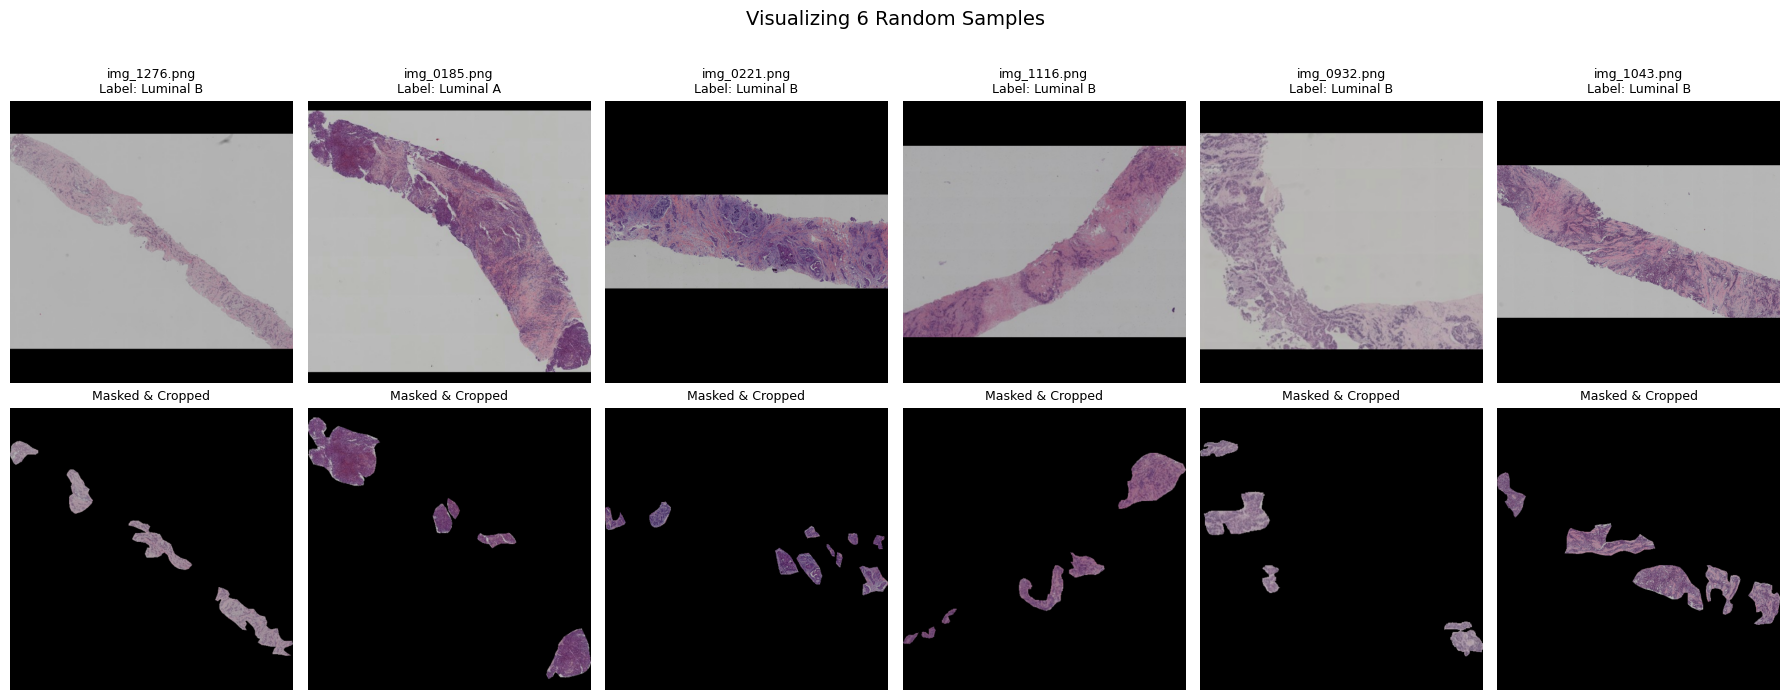

In [17]:
train_cache_paths = (TRAIN_IMAGES_CACHE_PATH, TRAIN_MASKS_CACHE_PATH, TRAIN_MASKED_IMAGES_CACHE_PATH)
raw_train, train_masks, train_images_masked, train_ids = load_and_process_pipeline(
    folder=TRAIN_DATA_PATH,
    cache_paths=train_cache_paths,
    whitelist_path=WHITELIST_PATH,
    target_size=IMAGE_SIZE
)

# 2. Load Labels
train_labels = load_labels_aligned(TRAIN_LABEL_PATH, train_ids)

# 3. Load Test Data (UINT8)
test_cache_paths = (TEST_IMAGE_CACHE_PATH, TEST_MASKS_CACHE_PATH, TEST_MASKED_IMAGES_CACHE_PATH)
raw_test, test_masks, test_images_masked, test_ids = load_and_process_pipeline(
    folder=TEST_DATA_PATH,
    cache_paths=test_cache_paths,
    whitelist_path=None,
    target_size=IMAGE_SIZE
)

print("-" * 30)
print(f"Train Images: {train_images_masked.shape} | Type: {train_images_masked.dtype}")
print(f"Test Images:  {test_images_masked.shape} | Type: {test_images_masked.dtype}")
print(f"Labels:       {len(train_labels)}")
print("-" * 30)

# 4. Plotting
if PLOT_FLAG: 
    train_filenames_aligned = [f"img_{uid}.png" for uid in train_ids]
    
    cplot.visualize_image_components(
        raw_train, 
        train_masks, 
        train_labels, 
        filenames=train_filenames_aligned, 
        num_samples=6
    )

## Dataloader creation

In [18]:
def make_loader(ds, batch_size, shuffle, drop_last):
    # Robust worker detection
    if os.name == 'nt': # Windows
        num_workers = 0 
    else: 
        num_workers = min(8, os.cpu_count() or 2)
        
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=(num_workers > 0), 
    )

def preprocess_inputs(images):
    # Input shape: (N, IMAGE_SIZE, IMAGE_SIZE, 3)
    
    # 1. Convert to float and arrange channels (N, 3, H, W)
    tensor = torch.from_numpy(images).float().permute(0, 3, 1, 2)
    print(f"Before normalization: Min: {tensor.min().item():.2f}, Max: {tensor.max().item():.2f}")

    # 2. Normalize [0, 255] -> [0, 1]
    tensor = tensor / 255.0 
    
    # 3. Print stats (Optional, but good for debugging)
    # Using .item() converts the 1-element tensor result to a standard Python float
    print(f"After Normalization: Min: {tensor.min().item():.2f}, Max: {tensor.max().item():.2f}")

    return tensor

# --- Setup Data ---
# 1. Use the filtered images we loaded previously
X_input = train_images_masked
train_labels_aligned = train_labels 

# --- 3. Safety Check ---
print(f"Images: {len(X_input)} | Labels: {len(train_labels_aligned)}")
if len(X_input) != len(train_labels_aligned):
    raise ValueError(f"Mismatch! Images: {len(X_input)}, Labels: {len(train_labels_aligned)}")

# --- 4. Prepare Tensor (Inputs) ---
X_tensor = preprocess_inputs(X_input)

# --- 5. Prepare Tensor (Labels) ---
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(train_labels_aligned)
Y_tensor = torch.from_numpy(y_encoded).long()

print(f"X Shape: {X_tensor.shape}")  # Should be (748, 3, 512, 512)
print(f"Y Shape: {Y_tensor.shape}")  # Should be (748,)

# --- 6. Split and Create Loaders ---
indices = np.arange(len(X_tensor))
train_idx, val_idx = train_test_split(
    indices, 
    test_size=VALIDATION_SIZE, 
    random_state=SEED, 
    stratify=y_encoded
)

train_ds = TensorDataset(X_tensor[train_idx], Y_tensor[train_idx])
val_ds   = TensorDataset(X_tensor[val_idx],   Y_tensor[val_idx])

# Create loaders
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader   = make_loader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# --- Summary ---
print("-" * 30)
print(f"Train Shape: {train_ds[0][0].shape} | Samples: {len(train_ds)}")
print(f"Val Shape:   {val_ds[0][0].shape} | Samples: {len(val_ds)}")
print("-" * 30)
for i, name in enumerate(label_encoder.classes_):
    print(f"  {i}: {name}")
print("-" * 30)

Images: 748 | Labels: 748


Before normalization: Min: 0.00, Max: 243.00
After Normalization: Min: 0.00, Max: 0.95
X Shape: torch.Size([748, 3, 512, 512])
Y Shape: torch.Size([748])
------------------------------
Train Shape: torch.Size([3, 512, 512]) | Samples: 598
Val Shape:   torch.Size([3, 512, 512]) | Samples: 150
------------------------------
  0: HER2(+)
  1: Luminal A
  2: Luminal B
  3: Triple negative
------------------------------


## CNN Model

### Model Architecture

In [19]:
class SimpleCNN(nn.Module):

    def __init__(self, input_shape=(3, 224, 224), num_classes=2, dropout_rate=0.2):
        super().__init__()

        # First convolutional block: 16 filters
        self.conv0 = nn.Conv2d(input_shape[0], 16, kernel_size=3, padding='same')
        self.relu0 = nn.ReLU()
        self.mp0 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Second convolutional block: 32 filters
        self.conv1 = nn.Conv2d(16, 32, kernel_size=3, padding='same')
        self.relu1 = nn.ReLU()
        self.mp1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Third convolutional block: 64 filters
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding='same')
        self.relu2 = nn.ReLU()
        self.mp2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Fourth convolutional block: 128 filters
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding='same')
        self.relu3 = nn.ReLU()

        # Calculate flattened size after all blocks using a dummy forward pass
        with torch.no_grad():
            dummy_input = torch.zeros(1, *input_shape)
            dummy_output = self._forward_features(dummy_input)
            flattened_size = dummy_output.view(1, -1).shape[1]

        # Classification head
        self.classifier_head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout_rate),
            nn.Linear(flattened_size, num_classes)
        )

    def _forward_features(self, x):
        """Forward pass through convolutional layers only."""
        x = self.mp0(self.relu0(self.conv0(x)))
        x = self.mp1(self.relu1(self.conv1(x)))
        x = self.mp2(self.relu2(self.conv2(x)))
        x = self.relu3(self.conv3(x))
        return x

    def forward(self, x):
        """Forward pass through the entire network."""
        x = self._forward_features(x)
        x = self.classifier_head(x)
        return x

### GradCam

In [31]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Hook the layer to capture gradients and activations
        # We use a weakref to avoid memory leaks or issues with deepcopy if needed
        self.handles = []
        self.handles.append(target_layer.register_forward_hook(self.save_activation))
        self.handles.append(target_layer.register_full_backward_hook(self.save_gradient))

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def remove_hooks(self):
        for handle in self.handles:
            handle.remove()

    def __call__(self, x, class_idx=None):
        # 1. Forward Pass
        self.model.eval()
        
        # Zero grads before starting
        self.model.zero_grad()
        
        logits = self.model(x)
        
        if class_idx is None:
            class_idx = logits.argmax(dim=1)
            
        # 2. Backward Pass
        score = logits[:, class_idx].squeeze()
        score.backward(retain_graph=True)
        
        # 3. Generate Map
        # Pool the gradients across the channels
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        
        # Weight the activations by the gradients
        # The activation map is usually (1, C, H, W)
        activation = self.activations[0]
        
        # Vectorized weighting is faster
        for i in range(activation.shape[0]):
            activation[i, :, :] *= pooled_gradients[i]
            
        # Average the channels to get a 2D heatmap
        heatmap = torch.mean(activation, dim=0).cpu().detach().numpy()
        
        # ReLU on top (we only care about positive influence)
        heatmap = np.maximum(heatmap, 0)
        
        # Normalize
        if np.max(heatmap) != 0:
            heatmap /= np.max(heatmap)
            
        return heatmap, logits

In [32]:
def plot_grad_cam(model, dataset, filenames, device, target_layer, num_samples=3):
    print(f"Generating Grad-CAM for {num_samples} samples using layer: {target_layer}...")
    
    # Initialize GradCAM with the specific layer
    grad_cam = GradCAM(model, target_layer)
    
    # Pick random indices
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5 * num_samples))
    
    try:
        for i, idx in enumerate(indices):
            # Prepare Input
            img_tensor = dataset[idx] # LazyDataset returns just the tensor (or tensor, label)
            if isinstance(img_tensor, tuple): 
                img_tensor = img_tensor[0]
                
            input_tensor = img_tensor.unsqueeze(0).to(device).requires_grad_(True)
            
            # Get Heatmap
            heatmap, logits = grad_cam(input_tensor)
            pred_idx = logits.argmax(dim=1).item()
            
            # Process Image for Display
            img_display = img_tensor.permute(1, 2, 0).cpu().numpy()
            img_display = np.clip(img_display, 0, 1)
            
            # Resize Heatmap to Image Size
            heatmap = cv2.resize(heatmap, (img_display.shape[1], img_display.shape[0]))
            
            # Convert heatmap to RGB
            heatmap_uint8 = np.uint8(255 * heatmap)
            heatmap_colored = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
            heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB) / 255.0
            
            # Overlay
            superimposed = heatmap_colored * 0.4 + img_display
            superimposed = np.clip(superimposed, 0, 1)
            
            # Plot
            # Col 1: Original
            ax = axes[i, 0] if num_samples > 1 else axes[0]
            ax.imshow(img_display)
            ax.set_title(f"{filenames[idx]}\nOriginal", fontsize=10)
            ax.axis('off')
            
            # Col 2: Heatmap
            ax = axes[i, 1] if num_samples > 1 else axes[1]
            ax.imshow(heatmap, cmap='jet')
            ax.set_title("Activation Heatmap", fontsize=10)
            ax.axis('off')
            
            # Col 3: Overlay
            ax = axes[i, 2] if num_samples > 1 else axes[2]
            ax.imshow(superimposed)
            ax.set_title(f"Prediction Class: {pred_idx}", fontsize=10)
            ax.axis('off')
            
        plt.tight_layout()
        plt.show()
        
    finally:
        # Important: Remove hooks to prevent memory leaks or interference with future inference
        grad_cam.remove_hooks()

### Training epoch

In [20]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0, l2_lambda=0):

    model.train()  # Set model to training mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Iterate through training batches
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Move data to device (GPU/CPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # Clear gradients from previous step
        optimizer.zero_grad(set_to_none=True)

        # Forward pass with mixed precision (if CUDA available)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
            logits = model(inputs)
            loss = criterion(logits, targets)

            # Add L1 and L2 regularization
            l1_norm = sum(p.abs().sum() for p in model.parameters())
            l2_norm = sum(p.pow(2).sum() for p in model.parameters())
            loss = loss + l1_lambda * l1_norm + l2_lambda * l2_norm

        # Backward pass with gradient scaling
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        # Accumulate metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_f1

### Validating epoch

In [21]:
def validate_one_epoch(model, val_loader, criterion, device):
    model.eval()  # Set model to evaluation mode

    running_loss = 0.0
    all_predictions = []
    all_targets = []

    # Disable gradient computation for validation
    with torch.no_grad():
        for inputs, targets in val_loader:
            # Move data to device
            inputs, targets = inputs.to(device), targets.to(device)

            # Forward pass with mixed precision (if CUDA available)
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
                loss = criterion(logits, targets)

            # Accumulate metrics
            running_loss += loss.item() * inputs.size(0)
            predictions = logits.argmax(dim=1)
            all_predictions.append(predictions.cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    # Calculate epoch metrics
    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_accuracy = f1_score(
        np.concatenate(all_targets),
        np.concatenate(all_predictions),
        average='weighted'
    )

    return epoch_loss, epoch_accuracy

In [22]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name=""):

    # Initialize metrics tracking
    training_history = {
        'train_loss': [], 'val_loss': [],
        'train_f1': [], 'val_f1': []
    }

    # Configure early stopping if patience is set
    if patience > 0:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    print(f"Training {epochs} epochs...")

    # Main training loop: iterate through epochs
    for epoch in range(1, epochs + 1):

        # Forward pass through training data, compute gradients, update weights
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda, l2_lambda
        )

        # Evaluate model on validation data without updating weights
        val_loss, val_f1 = validate_one_epoch(
            model, val_loader, criterion, device
        )

        # Store metrics for plotting and analysis
        training_history['train_loss'].append(train_loss)
        training_history['val_loss'].append(val_loss)
        training_history['train_f1'].append(train_f1)
        training_history['val_f1'].append(val_f1)



        # Print progress every N epochs or on first epoch
        if verbose > 0:
            if epoch % verbose == 0 or epoch == 1:
                print(f"Epoch {epoch:3d}/{epochs} | "
                    f"Train: Loss={train_loss:.4f}, F1 Score={train_f1:.4f} | "
                    f"Val: Loss={val_loss:.4f}, F1 Score={val_f1:.4f}")

        # Early stopping logic: monitor metric and save best model
        if patience > 0:
            current_metric = training_history[evaluation_metric][-1]
            is_improvement = (current_metric > best_metric) if mode == 'max' else (current_metric < best_metric)

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # Restore best model weights if early stopping was used
    if restore_best_weights and patience > 0:
        model.load_state_dict(torch.load("models/"+experiment_name+'_model.pt'))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric} {best_metric:.4f}")

    # Save final model if no early stopping
    if patience == 0:
        torch.save(model.state_dict(), "models/"+experiment_name+'_model.pt')

    # Close TensorBoard writer
    if writer is not None:
        writer.close()

    return model, training_history

### Training

In [23]:
# Instantiate CNN model and move to computing device (CPU/GPU)
input_shape = train_ds[0][0].shape 
num_classes = len(label_encoder.classes_)
vanilla_model = SimpleCNN(
    input_shape,
    num_classes,
    dropout_rate=DROPOUT_RATE
).to(device)

# Display model architecture summary
#summary(vanilla_model, input_size=input_shape)
#model_graph = draw_graph(vanilla_model, input_size=(BATCH_SIZE,)+input_shape, expand_nested=True)
#model_graph.visual_graph

# Set up TensorBoard logging and save model architecture
experiment_name = "vanilla_cnn"
x = torch.randn(1, input_shape[0], input_shape[1], input_shape[2]).to(device)

# Define optimizer with L2 regularization
optimizer = torch.optim.Adam(vanilla_model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)

# Enable mixed precision training for GPU acceleration
scaler = torch.amp.GradScaler(enabled=(device.type == 'cuda'))

# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [ ]:
# Train model and track training history
vanilla_model, vanilla_history = fit(
    model=vanilla_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=CRITERION,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=None,
    verbose=1,
    experiment_name="vanilla_cnn",
    patience=PATIENCE
)

# Update best model if current performance is superior
if vanilla_history['val_f1'][-1] > best_performance:
    best_model = vanilla_model
    best_performance = vanilla_history['val_f1'][-1]

# Calculate and print the final validation F1 score
final_val_f1 = round(max(vanilla_history['val_f1']), 2)
print(f'Final validation F1 score: {final_val_f1}%')

Training 300 epochs...
Epoch   1/300 | Train: Loss=1.3315, F1 Score=0.2052 | Val: Loss=1.3072, F1 Score=0.1967
Epoch   2/300 | Train: Loss=1.3017, F1 Score=0.1994 | Val: Loss=1.3027, F1 Score=0.2114
Epoch   3/300 | Train: Loss=1.2828, F1 Score=0.2574 | Val: Loss=1.3031, F1 Score=0.1967
Epoch   4/300 | Train: Loss=1.2641, F1 Score=0.2633 | Val: Loss=1.3099, F1 Score=0.2498
Epoch   5/300 | Train: Loss=1.2169, F1 Score=0.3610 | Val: Loss=1.3146, F1 Score=0.3221
Epoch   6/300 | Train: Loss=1.1604, F1 Score=0.4963 | Val: Loss=1.3686, F1 Score=0.2839
Epoch   7/300 | Train: Loss=1.0523, F1 Score=0.5436 | Val: Loss=1.4283, F1 Score=0.3242
Epoch   8/300 | Train: Loss=0.9418, F1 Score=0.5832 | Val: Loss=1.5494, F1 Score=0.3235
Epoch   9/300 | Train: Loss=0.8199, F1 Score=0.6478 | Val: Loss=1.6729, F1 Score=0.3136
Epoch  10/300 | Train: Loss=0.7218, F1 Score=0.6988 | Val: Loss=1.7989, F1 Score=0.2993
Epoch  11/300 | Train: Loss=0.6250, F1 Score=0.7770 | Val: Loss=2.0202, F1 Score=0.3065
Epoch  12

#### Plot Results

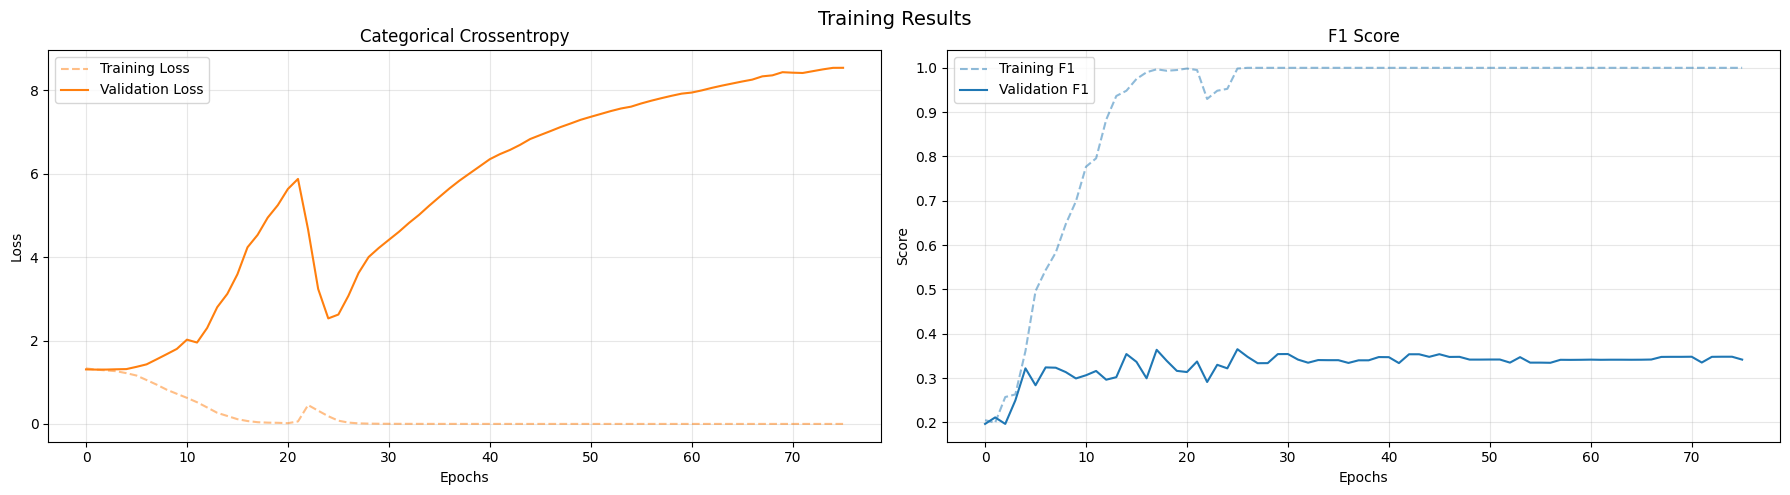

In [25]:
if PLOT_FLAG:
    cplot.plot_training_history(vanilla_history, title=f"Training Results")

## Test Prediction

In [33]:
def get_predictions(model, loader, device):
    print(f"--- Starting Inference on {len(loader.dataset)} Samples ---")
    model.eval()
    all_predictions = []
    
    with torch.no_grad():
        for batch in loader:
            # Handle list/tuple vs single tensor
            inputs = batch[0] if isinstance(batch, (list, tuple)) else batch
            inputs = inputs.to(device)
            
            with torch.amp.autocast(device_type=device.type, enabled=(device.type == 'cuda')):
                logits = model(inputs)
            
            preds = logits.argmax(dim=1).cpu().numpy()
            all_predictions.extend(preds)
            
    print("Inference complete.")
    return np.array(all_predictions)

In [34]:

def create_submission_csv(predictions, filenames, encoder, output_csv="submission.csv"):

    if len(predictions) != len(filenames):
        raise ValueError(f"Mismatch: {len(predictions)} predictions vs {len(filenames)} filenames")

    print(f"Decoding {len(predictions)} labels...")
    predicted_labels = encoder.inverse_transform(predictions)
    
    submission_df = pd.DataFrame({
        'sample_index': filenames,
        'label': predicted_labels
    })
    
    submission_df.to_csv(output_csv, index=False)
    print(f"Saved submission to '{output_csv}'")
    print(submission_df.head())
    
    return submission_df

Preprocessing Test Data...
Before normalization: Min: 0.00, Max: 247.00
After Normalization: Min: 0.00, Max: 0.97
Test Shape:  torch.Size([3, 512, 512]) | Samples: 954
Generating Grad-CAM for 4 samples using layer: Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)...


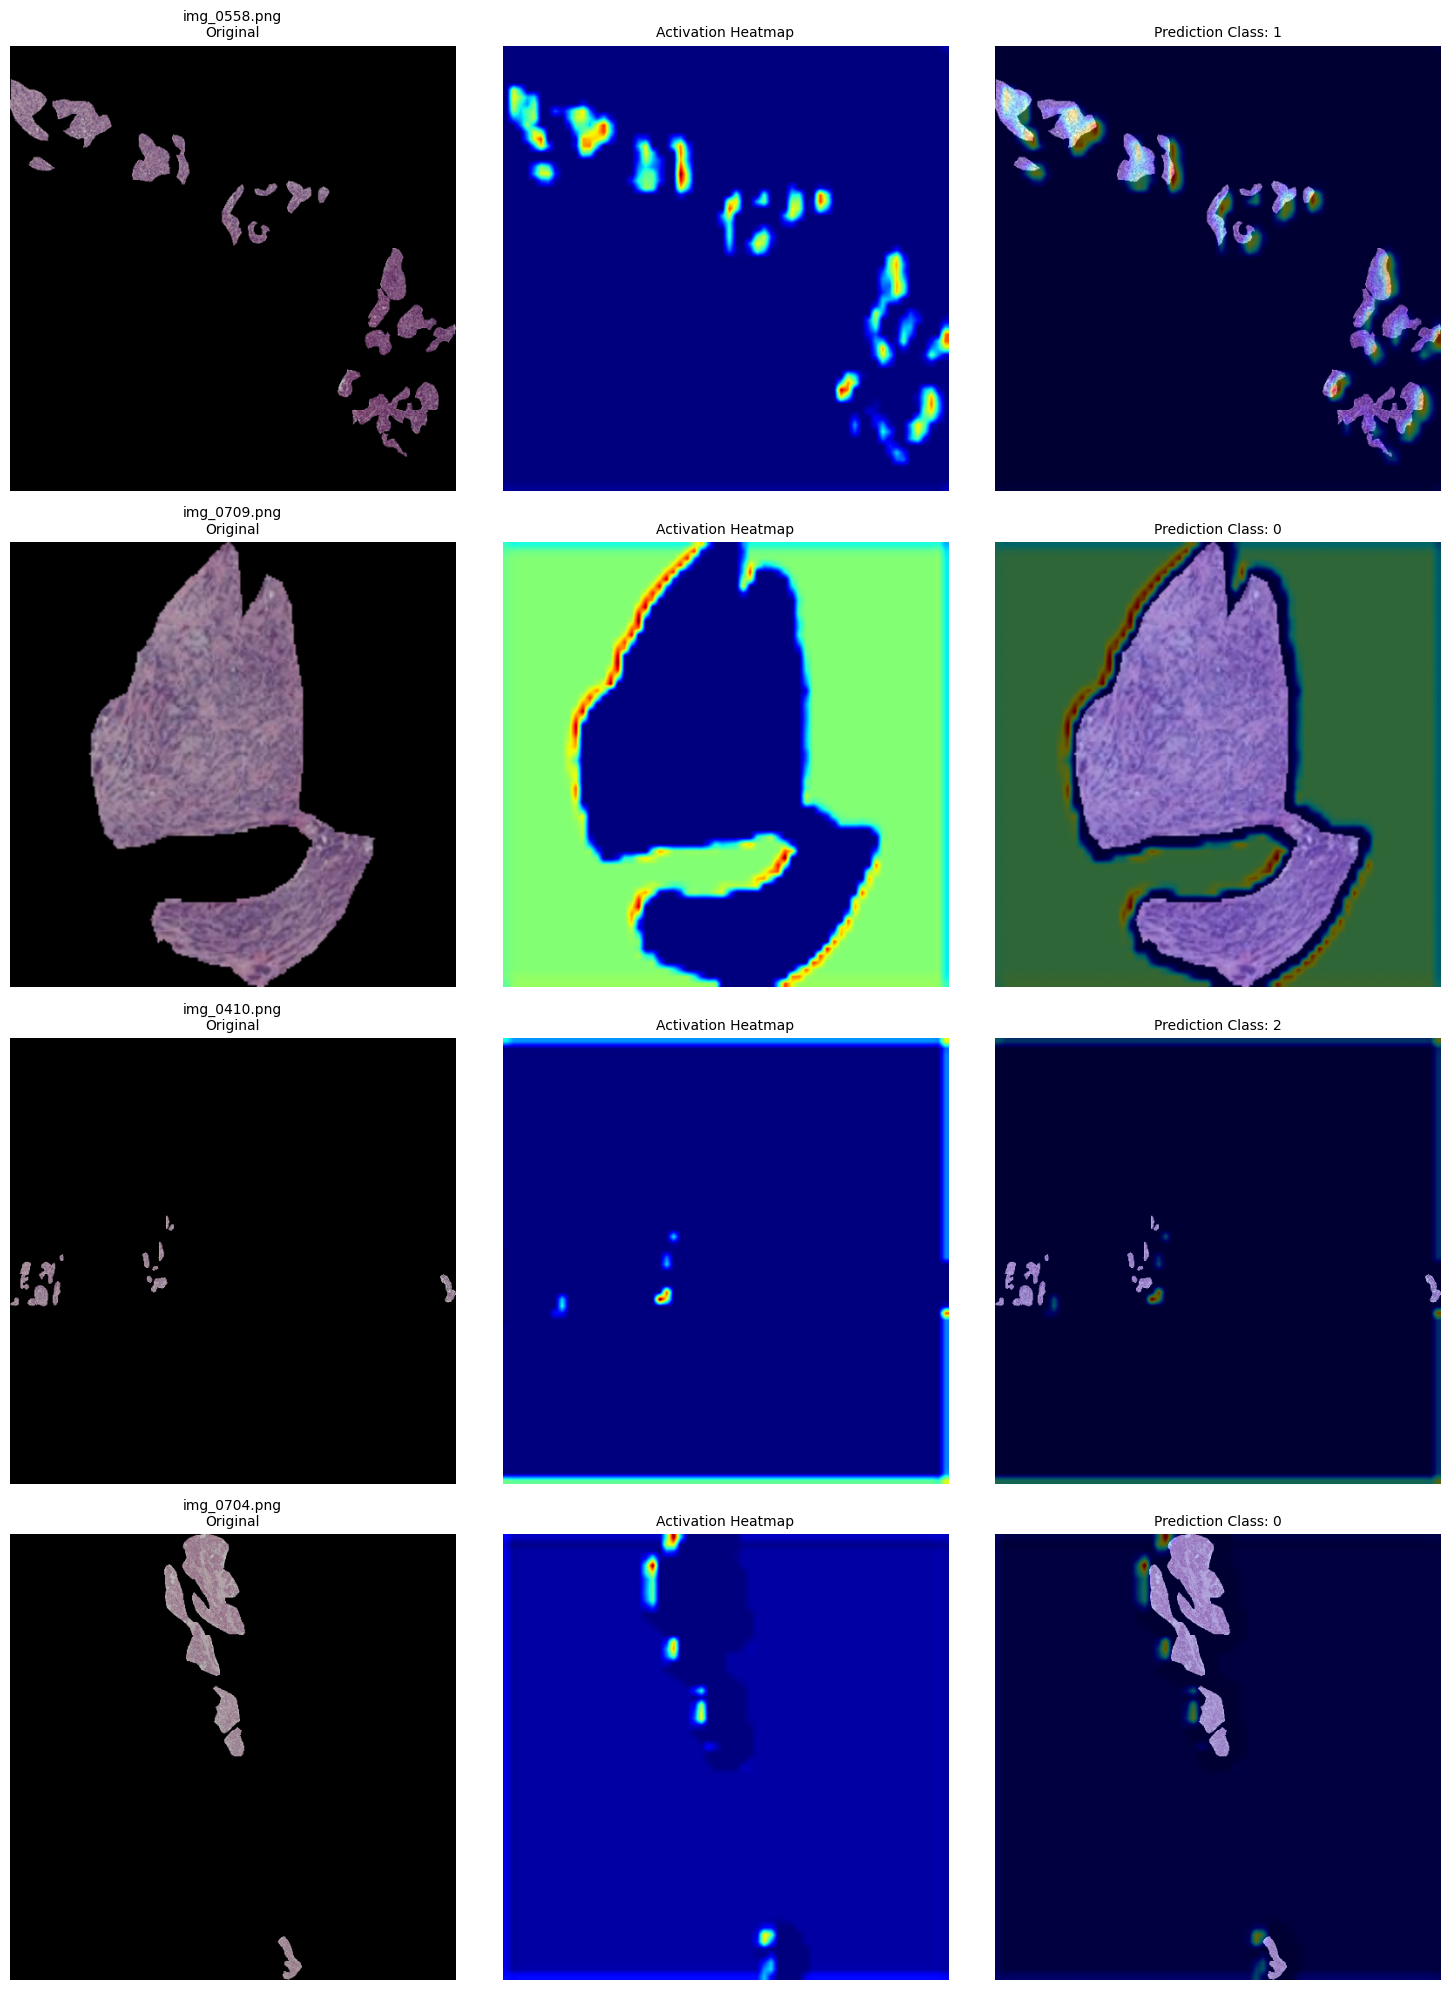

--- Starting Inference on 954 Samples ---
Inference complete.
Decoding 954 labels...
Saved submission to 'submission.csv'
   sample_index      label
0  img_0000.png  Luminal B
1  img_0001.png  Luminal A
2  img_0002.png    HER2(+)
3  img_0003.png    HER2(+)
4  img_0004.png  Luminal B


In [36]:
# --- Prepare Test Data ---
print("Preprocessing Test Data...")
X_test_tensor = preprocess_inputs(test_images_masked) 
test_ds = TensorDataset(X_test_tensor)

# --- Create Test Loader Only ---
test_loader = make_loader(test_ds, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_filenames = get_sorted_filenames(TEST_DATA_PATH)

print(f"Test Shape:  {test_ds[0][0].shape} | Samples: {len(test_ds)}")

# --- Run Prediction ---
if 'best_model' not in locals():
    best_model = vanilla_model

target_layer = best_model.conv3 
test_ds_viz = TensorDataset(X_test_tensor)
# Run Plotter
plot_grad_cam(
    best_model, 
    test_ds_viz, 
    filenames=test_filenames, 
    device=device, 
    target_layer=target_layer, 
    num_samples=4
)

raw_predictions = get_predictions(best_model, test_loader, device)

# --- Generate Submission ---
_ = create_submission_csv(
    predictions=raw_predictions,
    filenames=test_filenames,
    encoder=label_encoder,
    output_csv="submission.csv"
)